# **INDIAN KIDS SCREEN TIME ANALYSIS**

## **LOADING DATASET**

In [2]:
import pandas as pd

# loading dataset
data = pd.read_csv("Indian_Kids_Screen_Time.csv")

# displaying first 5 rows
data.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


## **UNDERSTANDING DATASET**

### **Checking Datatype of columns**

In [8]:
data.dtypes

Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
dtype: object

### **Checking info. of the the column types**

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


### **Checking for Null values in the Dataset**

In [3]:
data.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

### **Replace 'None' with 'No Health Impact'**

In [11]:
data['Health_Impacts'] = data['Health_Impacts'].fillna('No Health Impact')
print("Data after replacing 'None':")
data.head()

Data after replacing 'None':


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


### **Checking for Null values in the Dataset after replacing it with No Health Impact**

In [13]:
data.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

### **Checking duplicate Values**

In [15]:
data.duplicated().sum()

np.int64(44)

### **Showing first 20 Duplicate rows**

In [16]:
data[data.duplicated(keep=False)].head(20)

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
369,14,Male,4.94,Smartphone,True,0.41,No Health Impact,Urban
646,16,Female,4.42,Laptop,True,0.35,"Poor Sleep, Anxiety",Urban
672,9,Female,0.00,Smartphone,False,0.60,No Health Impact,Urban
717,10,Male,0.00,Smartphone,False,0.50,No Health Impact,Urban
782,9,Male,0.00,Smartphone,False,0.41,No Health Impact,Urban
968,10,Female,0.00,Smartphone,False,0.43,No Health Impact,Urban
969,8,Female,0.00,Smartphone,False,0.53,No Health Impact,Urban
996,16,Female,4.42,Laptop,True,0.35,"Poor Sleep, Anxiety",Urban
1099,8,Female,0.00,Smartphone,False,0.43,No Health Impact,Urban
1172,8,Female,0.00,Smartphone,False,0.59,No Health Impact,Urban


### **Removing the duplicates**

In [8]:
data = data.drop_duplicates()

### **Checking for duplicates after removing the duplicates**

In [7]:
data.duplicated().sum()

np.int64(0)

## **CREATING SUBCATEGORIES**

### **Creating age bands**

In [21]:
age_bins = [8, 12, 16, 18]
age_labels = ['Child', 'Pre-Teen', 'Teenager']

data['Age_Band'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

# Moving Age_Band right after Age column
col = data.pop('Age_Band')
age_index = data.columns.get_loc('Age')
data.insert(age_index + 1, 'Age_Band', col)

print("\nData with Age Bands:")
data.head()



Data with Age Bands:


,Age,Age_Band,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Pre-Teen,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Child,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Teenager,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Pre-Teen,Female,1.21,Laptop,False,0.39,No Health Impact,Urban
4,12,Child,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


### **Categorize Health Impacts**

In [23]:
def categorize_health_impact(impact):
    physical_impacts = ['Poor Sleep', 'Eye Strain', 'Obesity Risk']
    mental_impacts = ['Anxiety']
    
    has_physical = any(p in impact for p in physical_impacts)
    has_mental = any(m in impact for m in mental_impacts)
    
    if has_physical and has_mental:
        return 'Both'
    elif has_physical:
        return 'Physical Health'
    elif has_mental:
        return 'Mental Health'
    else:
        return 'No Health Impact'

# Creating the new category column
data['Health_Impact_Category'] = data['Health_Impacts'].apply(categorize_health_impact)

# Moving it next to Health_Impacts
col = data.pop('Health_Impact_Category')
health_index = data.columns.get_loc('Health_Impacts')
data.insert(health_index + 1, 'Health_Impact_Category', col)

print("\nData with Health Category:")
data.head(10)



Data with Health Category:


,Age,Age_Band,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Health_Impact_Category,Urban_or_Rural
0,14,Pre-Teen,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Physical Health,Urban
1,11,Child,Female,4.61,Laptop,True,0.30,Poor Sleep,Physical Health,Urban
2,18,Teenager,Female,3.73,TV,True,0.32,Poor Sleep,Physical Health,Urban
3,15,Pre-Teen,Female,1.21,Laptop,False,0.39,No Health Impact,No Health Impact,Urban
4,12,Child,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Both,Urban
5,14,Pre-Teen,Female,4.88,Smartphone,True,0.44,Poor Sleep,Physical Health,Urban
6,17,Teenager,Male,2.97,TV,False,0.48,No Health Impact,No Health Impact,Rural
7,10,Child,Male,2.74,TV,True,0.54,No Health Impact,No Health Impact,Urban
8,14,Pre-Teen,Male,4.61,Laptop,True,0.36,"Poor Sleep, Anxiety",Both,Rural
9,18,Teenager,Male,3.24,Tablet,True,0.48,"Poor Sleep, Obesity Risk",Physical Health,Urban


### **Creating the new 'Device_Category' column**

In [25]:
def categorize_device(device):
    if device == 'TV':
        return 'Fixed TV (>30" inch)'
    else:
        return 'Portable (<30" inch)'

# Creating the new column
data['Device_Category'] = data['Primary_Device'].apply(categorize_device)

# Moving it next to Primary_Device
col = data.pop('Device_Category')
device_index = data.columns.get_loc('Primary_Device')
data.insert(device_index + 1, 'Device_Category', col)

print("\nData with Device Category:")
data.head(10)



Data with Device Category:


,Age,Age_Band,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Device_Category,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Health_Impact_Category,Urban_or_Rural
0,14,Pre-Teen,Male,3.99,Smartphone,"Portable (<30"" inch)",True,0.42,"Poor Sleep, Eye Strain",Physical Health,Urban
1,11,Child,Female,4.61,Laptop,"Portable (<30"" inch)",True,0.30,Poor Sleep,Physical Health,Urban
2,18,Teenager,Female,3.73,TV,"Fixed TV (>30"" inch)",True,0.32,Poor Sleep,Physical Health,Urban
3,15,Pre-Teen,Female,1.21,Laptop,"Portable (<30"" inch)",False,0.39,No Health Impact,No Health Impact,Urban
4,12,Child,Female,5.89,Smartphone,"Portable (<30"" inch)",True,0.49,"Poor Sleep, Anxiety",Both,Urban
5,14,Pre-Teen,Female,4.88,Smartphone,"Portable (<30"" inch)",True,0.44,Poor Sleep,Physical Health,Urban
6,17,Teenager,Male,2.97,TV,"Fixed TV (>30"" inch)",False,0.48,No Health Impact,No Health Impact,Rural
7,10,Child,Male,2.74,TV,"Fixed TV (>30"" inch)",True,0.54,No Health Impact,No Health Impact,Urban
8,14,Pre-Teen,Male,4.61,Laptop,"Portable (<30"" inch)",True,0.36,"Poor Sleep, Anxiety",Both,Rural
9,18,Teenager,Male,3.24,Tablet,"Portable (<30"" inch)",True,0.48,"Poor Sleep, Obesity Risk",Physical Health,Urban


# **UNIVARIATE AND BIVARIATE VISUAL ANALYSIS**

## **Univariate Visual Analysis**

In [27]:
import warnings
warnings.filterwarnings("ignore")

### **Screen Time**

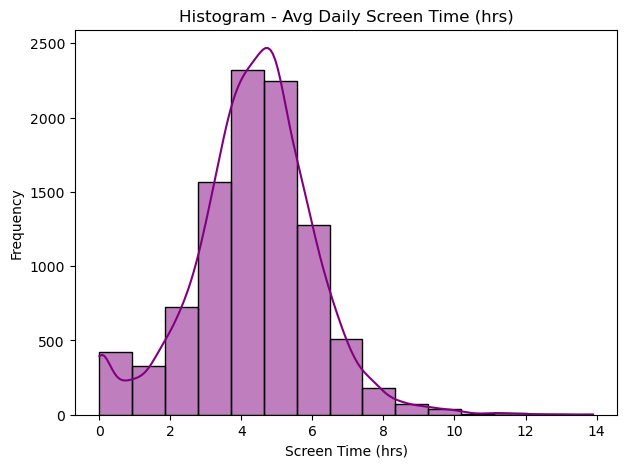

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ===================================================
# Screen Time
# ===================================================
# --- Histogram ---
plt.figure(figsize=(7,5))
sns.histplot(data['Avg_Daily_Screen_Time_hr'], bins=15, kde=True, color="purple")
plt.title("Histogram - Avg Daily Screen Time (hrs)")
plt.xlabel("Screen Time (hrs)")
plt.ylabel("Frequency")
plt.show()


### **Age Band**

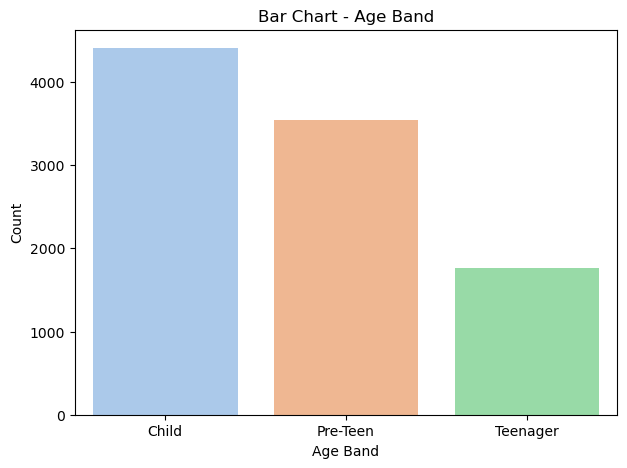

In [42]:
# --- Bar Chart ---
plt.figure(figsize=(7,5))
sns.countplot(x='Age_Band', data=data, palette="pastel")
plt.title("Bar Chart - Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

### **Primary Device**

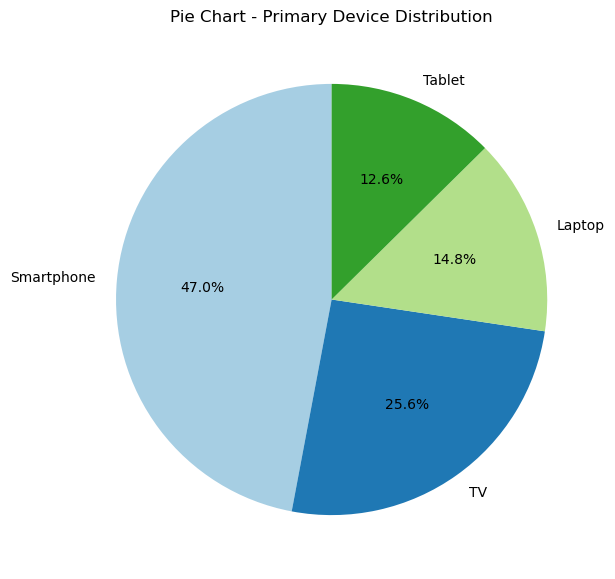

In [40]:
# --- Pie Chart ---
plt.figure(figsize=(7,7))
data['Primary_Device'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Pie Chart - Primary Device Distribution")
plt.ylabel("")
plt.show()

## **Bivariate Visual Analysis**

###  **Screen Time vs Age Band**

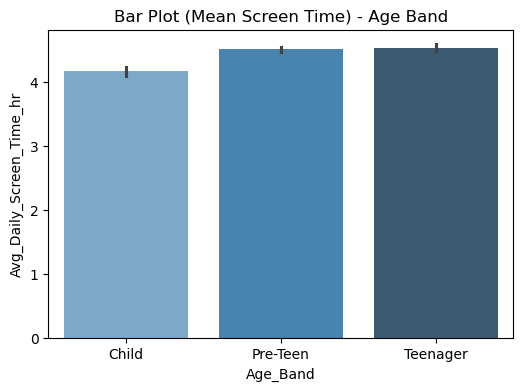

In [44]:
plt.figure(figsize=(6,4))
sns.barplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=data, palette="Blues_d", estimator='mean')
plt.title("Bar Plot (Mean Screen Time) - Age Band")
plt.show()

###  **Screen Time vs Gender**

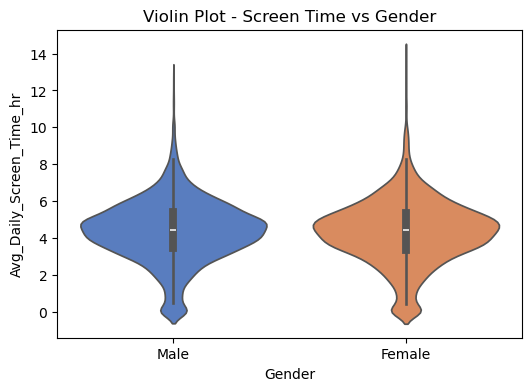

In [46]:
plt.figure(figsize=(6,4))
sns.violinplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=data, palette="muted")
plt.title("Violin Plot - Screen Time vs Gender")
plt.show()

### **Screen Time vs Urban_or_Rural (Location Type)**

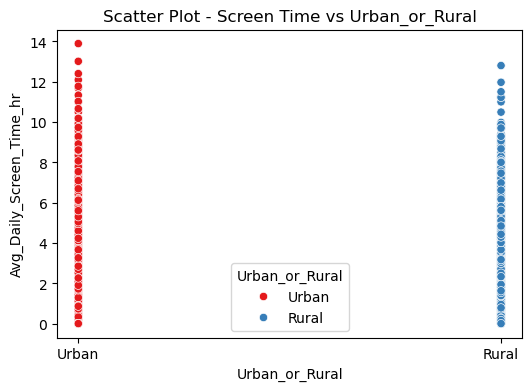

In [48]:
# ===================================================
# Screen Time vs Urban_or_Rural (Location Type)
# ===================================================
plt.figure(figsize=(6,4))
sns.scatterplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=data, hue='Urban_or_Rural', palette="Set1")
plt.title("Scatter Plot - Screen Time vs Urban_or_Rural")
plt.show()